# Exploring the rank of trained Neural Networks

In this Final assignment, you're going to explore trained neural networks, and study the rank of its matrices.

**Reminder**: The rank is the number of independent columns of the matrix. If a matrix $A \in \mathbb{R}^{n\times m}$  has rank $k$, then $A$ can be approximated by

$$A \approx B \cdot C$$

where $B \in \mathbb{R}^{n\times k}$ and $C \in \mathbb{R}^{k\times m}$.

You can find the rank of matrix $A$ by performing Gaussian elimination and counting the number of pivots. This can be done in few lines of `numpy` code.

**References**:
- https://arxiv.org/pdf/1804.08838
- https://arxiv.org/pdf/2209.13569
- https://arxiv.org/pdf/2012.13255

Note: The references above are not needed to complete this notebook, but reading them might give you additional insights.

## Important

1. For all the training done, make sure to plot things like the loss values and accuracy on each epoch.

    - You can either use tensorboard or just make a static matplotlib plot.
    
2. Don't add biases to the layers in the network, not important for this notebook.
3. No need to use Dropout or BatchNorm on the network.
4. Remember to use GPUs during the training.
5. Always test your hypothesis on both training and testing sets, you might get a surprising result sometimes.

## Task 1: Downloading MNIST and Dataloaders

Download the MNIST dataset and split into training and testing, and create dataloaders.

Link: https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html

In [2]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


transform = transforms.Compose([
    transforms.ToTensor(),
    # Normalize using MNIST mean and standard deviation
    transforms.Normalize((0.1307,), (0.3081,))
])






train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)


train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)


#checking downloaded data
for batch_idx, (data, target) in enumerate(train_loader):
    print(f"Batch {batch_idx}: data shape {data.shape}, target shape {target.shape}")

    if batch_idx == 0:
        break

print("Data loaders for training and testing are ready.")



Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 9912422/9912422 [00:00<00:00, 37722131.46it/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 28881/28881 [00:00<00:00, 1089996.71it/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 1648877/1648877 [00:00<00:00, 9954861.85it/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 4542/4542 [00:00<00:00, 7740970.65it/s]


Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw

Batch 0: data shape torch.Size([64, 1, 28, 28]), target shape torch.Size([64])
Data loaders for training and testing are ready.


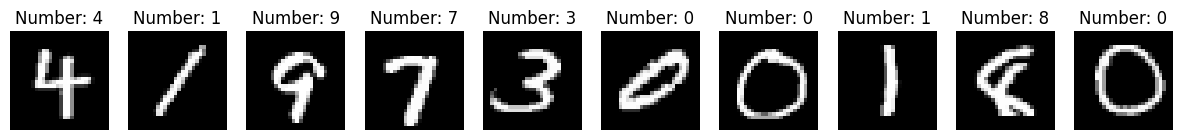

In [ ]:

#checking the correctness of the downloaded data. for this purpose I visualize them
fig, axes = plt.subplots(1, 10, figsize=(15, 3))
for i in range(10):
    image = data[i].numpy().squeeze()
    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(f"Number: {target[i].item()}")
    axes[i].axis('off')

plt.show()

## Task 2: Train a neural network

Build a simple Multi-layered Perceptron with ReLU activations, and train it on MNIST until achieving 95% accuracy or higher.



##I'll make 2 NNs with different optimizers. In the first case, the optimizer will be SGD, and in the second, Adam.

##I will use the SGD optimizer to better understand the main qualities of my NN and make sure that the success of the model is not only due to a powerful optimizer(Adam).

##**1.** with SGD optimizer

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.tensorboard import SummaryWriter
from torch.nn.modules import loss
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

class Flatten(nn.Module):
    def forward(self, x):
        batch_size = x.shape[0]
        return x.view(batch_size, -1)

def get_model():
    return nn.Sequential(
        Flatten(),
        nn.Linear(784, 512),
        nn.ReLU(),
        nn.Linear(512, 64),
        nn.ReLU(),
        nn.Linear(64, 10)
    )

loss_function = loss.CrossEntropyLoss()

def train(model, train_loader, optimizer, loss_function, epoch, writer):
    model.train()
    train_loss = 0
    correct = 0
    total = 0
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        output = model(data)
        loss = loss_function(output, target)
        train_loss += loss.item()
        loss.backward()
        optimizer.step()

        pred = output.argmax(dim=1, keepdim=True)
        correct += pred.eq(target.view_as(pred)).sum().item()
        total += target.size(0)

        if batch_idx % 200 == 0:
            print(f'Train Epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)} '
                  f'({100. * batch_idx / len(train_loader):.0f}%)]\tLoss: {loss.item():.6f}')

    train_loss /= len(train_loader.dataset)
    train_accuracy = 100. * correct / total

    writer.add_scalar('train-loss', train_loss, global_step=epoch)
    writer.add_scalar('train-accuracy', train_accuracy, global_step=epoch)

    return train_accuracy

def test(model, test_loader, loss_function, epoch, writer):
    model.eval()
    test_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in test_loader:
            output = model(data)
            test_loss += loss_function(output, target).item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
            total += target.size(0)

    test_loss /= len(test_loader.dataset)
    test_accuracy = 100. * correct / total

    writer.add_scalar('test-loss', test_loss, global_step=epoch)
    writer.add_scalar('test-accuracy', test_accuracy, global_step=epoch)
    print(f'\nTest set: Average loss: {test_loss:.4f}, Accuracy: {correct}/{len(test_loader.dataset)} '
          f'({test_accuracy:.2f}%)\n')

    return test_accuracy

In [18]:
# I set it to 100 epochs, because training will stop automatically when Accuracy reaches 95%+/95%
def train_with_lr_SGD(lr, model, train_loader, test_loader, epochs=100, start_epoch=0):
    writer = SummaryWriter(log_dir=f'logs1/lr_{lr}')
    optimizer = optim.SGD(model.parameters(), lr=lr)
    for epoch in range(start_epoch, start_epoch + epochs):
        train_accuracy = train(model, train_loader, optimizer, loss_function, epoch, writer)
        test_accuracy = test(model, test_loader, loss_function, epoch, writer)

        if test_accuracy >= 95.0:
            print(f'Training stopped early at epoch {epoch} with train accuracy {train_accuracy:.2f}% '
                  f'and test accuracy {test_accuracy:.2f}%')
            break

    writer.close()


In [ ]:

model_1 = get_model()


#I will use lr, which is specified in the documentation
# torch.optim.SGD(params, lr=0.001, momentum=0, dampening=0, weight_decay=0, nesterov=False, *, maximize=False, foreach=None, differentiable=False, fused=None)
train_with_lr_SGD(0.001, model_1, train_loader, test_loader)

Train Epoch: 0 [0/60000 (0%)]	Loss: 2.310691
Train Epoch: 0 [12800/60000 (21%)]	Loss: 2.230459
Train Epoch: 0 [25600/60000 (43%)]	Loss: 2.195136
Train Epoch: 0 [38400/60000 (64%)]	Loss: 2.098491
Train Epoch: 0 [51200/60000 (85%)]	Loss: 1.981065

Test set: Average loss: 0.0019, Accuracy: 6588/10000 (65.88%)

Train Epoch: 1 [0/60000 (0%)]	Loss: 1.886915
Train Epoch: 1 [12800/60000 (21%)]	Loss: 1.784976
Train Epoch: 1 [25600/60000 (43%)]	Loss: 1.539441
Train Epoch: 1 [38400/60000 (64%)]	Loss: 1.370711
Train Epoch: 1 [51200/60000 (85%)]	Loss: 1.173119

Test set: Average loss: 0.0011, Accuracy: 7672/10000 (76.72%)

Train Epoch: 2 [0/60000 (0%)]	Loss: 1.230991
Train Epoch: 2 [12800/60000 (21%)]	Loss: 1.195126
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.866225
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.860189
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.822178

Test set: Average loss: 0.0007, Accuracy: 8284/10000 (82.84%)

Train Epoch: 3 [0/60000 (0%)]	Loss: 0.697665
Train Epoch: 3 [12800/60000 

##**2.** with Adam optimizer

In [4]:


#I set it to 100 epochs, because training will stop automatically when Accuracy reaches 95%+/95%
def train_with_lr_Adam(lr, model, train_loader, test_loader, epochs=100, start_epoch=0):
    writer = SummaryWriter(log_dir=f'logs1/lr_{lr}')
    optimizer = optim.Adam(model.parameters(), lr=lr)
    for epoch in range(start_epoch, start_epoch + epochs):
        train_accuracy = train(model, train_loader, optimizer, loss_function, epoch, writer)
        test_accuracy = test(model, test_loader, loss_function, epoch, writer)

        if test_accuracy >= 95.0:
            print(f'Training stopped early at epoch {epoch} with train accuracy {train_accuracy:.2f}% '
                  f'and test accuracy {test_accuracy:.2f}%')
            break

    writer.close()


In [13]:
model_2=get_model()
'''
I understand that Adam adapts learning rates for each parameter individually.
But I will set the base learning rate during initialization, because this is an important hyperparameter.
I will use the recommended value lr = 0.001 from the documentation
(CLASStorch.optim.Adam(params, lr=0.001, betas=(0.9, 0.999), eps=1e-08, weight_decay=0, amsgrad=False, *, foreach=None, maximize=False, capturable=False, differentiable=False, fused=None))


'''
%time train_with_lr_Adam(0.001,model_2, train_loader, test_loader)

Train Epoch: 0 [0/60000 (0%)]	Loss: 2.300153
Train Epoch: 0 [12800/60000 (21%)]	Loss: 0.191079
Train Epoch: 0 [25600/60000 (43%)]	Loss: 0.182200
Train Epoch: 0 [38400/60000 (64%)]	Loss: 0.157006
Train Epoch: 0 [51200/60000 (85%)]	Loss: 0.084536

Test set: Average loss: 0.0001, Accuracy: 9684/10000 (96.84%)

Training stopped early at epoch 0 with train accuracy 93.32% and test accuracy 96.84%
CPU times: user 27.7 s, sys: 119 ms, total: 27.9 s
Wall time: 28.1 s


## Task 3: Analyze the rank of the matrices in this network

Perform experiments and answer the following questions:
- What's the average rank of the matrices on all layers?
- How does the rank increase as we go to deeper layers?
- Try the same MLP, but change the activation function to others ($\tanh, \sigma, \dots$). Do the answers change?

##1. What's the average rank of the matrices on all layers?

##The maximum value of the rank of the weight matrix in the neural network layer is equal to the minimum value between the number of input and output neurons.

In [6]:
import numpy as np

#Get weights for each model layer
weights_1 = model_2[1].weight.detach().numpy()
weights_2 = model_2[3].weight.detach().numpy()
weights_3 = model_2[5].weight.detach().numpy()

#Counting the rank
rank_1 = np.linalg.matrix_rank(weights_1)
rank_2 = np.linalg.matrix_rank(weights_2)
rank_3 = np.linalg.matrix_rank(weights_3)

print(f"Rank of the matrix of the first layer: {rank_1}")
print(f"Rank of the matrix of the second layer: {rank_2}")
print(f"Rank of the matrix of the third layer: {rank_3}")


Rank of the matrix of the first layer: 512
Rank of the matrix of the second layer: 64
Rank of the matrix of the third layer: 10


In [16]:
def compute_rank(matrix):
    u, s, vh = torch.svd(matrix)
    rank = (s > 1e-5).sum().item()  # We use a small threshold for numerical stability
    return rank

def analyze_ranks(model):
    ranks = []
    for layer in model:
        if isinstance(layer, nn.Linear):
            weight_matrix = layer.weight.data
            rank = compute_rank(weight_matrix)
            ranks.append(rank)
            print(f'Layer {layer}: rank = {rank}')
    return ranks

In [17]:
ranks = analyze_ranks(model_2)
average_rank = np.mean(ranks)
print(f'Average rank of weight matrices: {average_rank}')


Layer Linear(in_features=784, out_features=512, bias=True): rank = 512
Layer Linear(in_features=512, out_features=64, bias=True): rank = 64
Layer Linear(in_features=64, out_features=10, bias=True): rank = 10
Average rank of weight matrices: 195.33333333333334


##2. How does the rank increase as we go to deeper layers?

##The ranks of the model weight matrices remained the maximum possible values

##As the layers get deeper, the rank of the matrices decreases, which is due to the fact that the network simplifies and generalizes data representations. The reasoning and experiments above are given as experimental evidence.Below are detailed explanations.

1. Our Flatten() is the input layer. For 28x28 MNIST images, each pixel is converted into a vector element of length 784 (since the MNIST image is 28x28).

2. First hidden layer:
(784 → 512):
This is a fully connected (linear) layer that takes 784 input values ​​(neurons) and outputs 512 values. This layer connects each of the 784 input neurons to the 512 neurons in the next layer. The maximum rank of this matrix can be 512, since it is the smaller of the two dimensions (784 and 512).

3. Second hidden layer:
 (512 → 64):
  The rank will be reduced compared to the first layer as the network begins to extract and simplify data representations. Maximum rank of the weight matrix: 64.
4. Output layer (64 → 10): The rank is further reduced since the model has already extracted important features in previous layers. And because we have 10 different numbers for classification, then at the output we have 10 neurons. Our output layer has 10 neurons, each of which corresponds to one of the numbers from 0 to 9. The maximum rank of the weight matrix is ​​10.


Thus, as the layers deepen, the maximum possible rank of matrices decreases, which reflects the process of simplification and selection of the most significant features at each layer of the network.

##3. Try the same MLP, but change the activation function to others ( tanh,σ,… ). Do the answers change?

In [25]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.tensorboard import SummaryWriter
from torch.nn.modules import loss
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


def get_model_tanh():
    return nn.Sequential(
        Flatten(),
        nn.Linear(784, 512),
        nn.Tanh(),
        nn.Linear(512, 64),
        nn.Tanh(),
        nn.Linear(64, 10)
    )


In [ ]:
model_3=get_model_tanh()

train_with_lr_Adam(0.001,model_3, train_loader, test_loader)

Train Epoch: 0 [0/60000 (0%)]	Loss: 2.317051
Train Epoch: 0 [12800/60000 (21%)]	Loss: 0.299439
Train Epoch: 0 [25600/60000 (43%)]	Loss: 0.178995
Train Epoch: 0 [38400/60000 (64%)]	Loss: 0.049422
Train Epoch: 0 [51200/60000 (85%)]	Loss: 0.186229


In [28]:
ranks_3 = analyze_ranks(model_3)
average_rank_3 = np.mean(ranks_3)
print(f'Average rank of weight matrices: {average_rank_3}')

Layer Linear(in_features=784, out_features=512, bias=True): rank = 512
Layer Linear(in_features=512, out_features=64, bias=True): rank = 64
Layer Linear(in_features=64, out_features=10, bias=True): rank = 10
Average rank of weight matrices: 195.33333333333334


In [ ]:
model_4=get_model_tanh()

train_with_lr_SGD(0.001,model_4, train_loader, test_loader)

Train Epoch: 0 [0/60000 (0%)]	Loss: 2.320437
Train Epoch: 0 [12800/60000 (21%)]	Loss: 2.089704
Train Epoch: 0 [25600/60000 (43%)]	Loss: 1.801180
Train Epoch: 0 [38400/60000 (64%)]	Loss: 1.637249
Train Epoch: 0 [51200/60000 (85%)]	Loss: 1.491104

Test set: Average loss: 0.0014, Accuracy: 7282/10000 (72.82%)

Train Epoch: 1 [0/60000 (0%)]	Loss: 1.462638
Train Epoch: 1 [12800/60000 (21%)]	Loss: 1.303075
Train Epoch: 1 [25600/60000 (43%)]	Loss: 1.192944
Train Epoch: 1 [38400/60000 (64%)]	Loss: 1.146776
Train Epoch: 1 [51200/60000 (85%)]	Loss: 1.041945

Test set: Average loss: 0.0010, Accuracy: 7987/10000 (79.87%)

Train Epoch: 2 [0/60000 (0%)]	Loss: 1.055530
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.949443
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.844715
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.824240
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.813891

Test set: Average loss: 0.0008, Accuracy: 8377/10000 (83.77%)

Train Epoch: 3 [0/60000 (0%)]	Loss: 0.762643
Train Epoch: 3 [12800/60000 

In [14]:
def get_model_Sigmoid():
    return nn.Sequential(
        Flatten(),
        nn.Linear(784, 512),
        nn.Sigmoid(),
        nn.Linear(512, 64),
        nn.Sigmoid(),
        nn.Linear(64, 10)
    )


In [30]:
model_5=get_model_Sigmoid()

train_with_lr_Adam(0.001,model_5, train_loader, test_loader)

Train Epoch: 0 [0/60000 (0%)]	Loss: 2.324918
Train Epoch: 0 [12800/60000 (21%)]	Loss: 0.445632
Train Epoch: 0 [25600/60000 (43%)]	Loss: 0.349924
Train Epoch: 0 [38400/60000 (64%)]	Loss: 0.284107
Train Epoch: 0 [51200/60000 (85%)]	Loss: 0.237006

Test set: Average loss: 0.0002, Accuracy: 9512/10000 (95.12%)

Training stopped early at epoch 0 with train accuracy 90.05% and test accuracy 95.12%


In [32]:
ranks_5 = analyze_ranks(model_5)
average_rank_5 = np.mean(ranks_5)
print(f'Average rank of weight matrices: {average_rank_3}')

Layer Linear(in_features=784, out_features=512, bias=True): rank = 512
Layer Linear(in_features=512, out_features=64, bias=True): rank = 64
Layer Linear(in_features=64, out_features=10, bias=True): rank = 10
Average rank of weight matrices: 195.33333333333334


##The ranks of the model weight matrices remained the maximum possible values

##And,no, the answer has not changed

In [19]:
model_6=get_model_Sigmoid()

train_with_lr_SGD(0.001,model_6, train_loader, test_loader)

Train Epoch: 0 [0/60000 (0%)]	Loss: 2.334738
Train Epoch: 0 [12800/60000 (21%)]	Loss: 2.338122
Train Epoch: 0 [25600/60000 (43%)]	Loss: 2.324471
Train Epoch: 0 [38400/60000 (64%)]	Loss: 2.306537
Train Epoch: 0 [51200/60000 (85%)]	Loss: 2.295343

Test set: Average loss: 0.0023, Accuracy: 1135/10000 (11.35%)

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.294529
Train Epoch: 1 [12800/60000 (21%)]	Loss: 2.283366
Train Epoch: 1 [25600/60000 (43%)]	Loss: 2.289147
Train Epoch: 1 [38400/60000 (64%)]	Loss: 2.301028
Train Epoch: 1 [51200/60000 (85%)]	Loss: 2.292941

Test set: Average loss: 0.0023, Accuracy: 1135/10000 (11.35%)

Train Epoch: 2 [0/60000 (0%)]	Loss: 2.290806
Train Epoch: 2 [12800/60000 (21%)]	Loss: 2.291379
Train Epoch: 2 [25600/60000 (43%)]	Loss: 2.287209
Train Epoch: 2 [38400/60000 (64%)]	Loss: 2.295671
Train Epoch: 2 [51200/60000 (85%)]	Loss: 2.279656

Test set: Average loss: 0.0023, Accuracy: 1135/10000 (11.35%)

Train Epoch: 3 [0/60000 (0%)]	Loss: 2.278658
Train Epoch: 3 [12800/60000 

In [20]:
def get_model_LeakyReLU():
    return nn.Sequential(
        Flatten(),
        nn.Linear(784, 512),
        nn.LeakyReLU(0.01),
        nn.Linear(512, 64),
        nn.LeakyReLU(0.01),
        nn.Linear(64, 10)
    )


In [21]:
model_7=get_model_LeakyReLU()

train_with_lr_Adam(0.001,model_7, train_loader, test_loader)

Train Epoch: 0 [0/60000 (0%)]	Loss: 2.316019
Train Epoch: 0 [12800/60000 (21%)]	Loss: 0.158067
Train Epoch: 0 [25600/60000 (43%)]	Loss: 0.105078
Train Epoch: 0 [38400/60000 (64%)]	Loss: 0.122892
Train Epoch: 0 [51200/60000 (85%)]	Loss: 0.164582

Test set: Average loss: 0.0001, Accuracy: 9597/10000 (95.97%)

Training stopped early at epoch 0 with train accuracy 93.45% and test accuracy 95.97%


In [31]:
ranks_7 = analyze_ranks(model_7)
average_rank_7 = np.mean(ranks_7)
print(f'Average rank of weight matrices: {average_rank_7}')

Layer Linear(in_features=784, out_features=512, bias=True): rank = 512
Layer Linear(in_features=512, out_features=64, bias=True): rank = 64
Layer Linear(in_features=64, out_features=10, bias=True): rank = 10
Average rank of weight matrices: 195.33333333333334


##The ranks of the model weight matrices remained the maximum possible values

##No, the answer has not changed

## Task 4: Overfit by scaling the MLP

1. Create a bigger network and train it on MNIST, to the point of overfitting.
2. Now check the rank of the matrices in the network, and answer the same questions.

##In order to overfit my NN I will increase the number of layers in your neural network and increase the number of neurons in each layer.

In [33]:
def get_model_Big_MLP():
    return nn.Sequential(
        Flatten(),
        nn.Linear(784, 1024),
        nn.ReLU(),
        nn.Linear(1024, 512),
        nn.ReLU(),
        nn.Linear(512, 256),
        nn.ReLU(),
        nn.Linear(256, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 10)
    )

In [5]:
def train_Big(model, train_loader, optimizer, loss_function, epoch, writer):
    model.train()
    train_loss = 0
    correct = 0
    total = 0
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        output = model(data)
        loss = loss_function(output, target)
        train_loss += loss.item()
        loss.backward()
        optimizer.step()

        pred = output.argmax(dim=1, keepdim=True)
        correct += pred.eq(target.view_as(pred)).sum().item()
        total += target.size(0)

        if batch_idx % 200 == 0:
            print(f'Train Epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)} '
                  f'({100. * batch_idx / len(train_loader):.0f}%)]\tLoss: {loss.item():.6f}')

    train_loss /= len(train_loader.dataset)
    train_accuracy = 100. * correct / total

    print(f'Train-loss: {train_loss}')
    print(f'Train-accuracy: {train_accuracy}')

    writer.add_scalar('train-loss', train_loss, global_step=epoch)
    writer.add_scalar('train-accuracy', train_accuracy, global_step=epoch)

    return train_accuracy

In [4]:
def test_Big(model, test_loader, loss_function, writer):
    model.eval()
    test_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in test_loader:
            output = model(data)
            test_loss += loss_function(output, target).item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
            total += target.size(0)

    test_loss /= len(test_loader.dataset)
    test_accuracy = 100. * correct / total

    print(f'\nTest set: Average loss: {test_loss:.4f}, Accuracy: {correct}/{len(test_loader.dataset)} '
          f'({test_accuracy:.2f}%)\n')

    return test_accuracy

In [54]:



def train_with_lr_Adam_Big(lr, model, train_loader, test_loader, epochs=25, start_epoch=0):
    writer = SummaryWriter(log_dir=f'logs1/lr_{lr}')
    optimizer = optim.Adam(model.parameters(), lr=lr)
    for epoch in range(start_epoch, start_epoch + epochs):
        train_accuracy = train_Big(model, train_loader, optimizer, loss_function, epoch, writer)
        '''
        When we want to retrain a model, we should not look at how it performs on test data during training.
        Those. we must reduce the generalizing ability of the model and select the most convenient
        coefficients exclusively for train data.
        '''
        #test_accuracy = test_Big(model, test_loader, loss_function, epoch, writer)
        if train_accuracy>=99.999:
            print(f'Training stopped early at epoch {epoch} with train accuracy {train_accuracy:.2f}% ')
            break


    writer.close()


In [55]:
big_model=get_model_Big_MLP()


##And I will also lower the learning rate so that the model remembers the data better

In [56]:
train_with_lr_Adam_Big(0.0001,big_model, train_loader, test_loader)

Train Epoch: 0 [0/60000 (0%)]	Loss: 2.305178
Train Epoch: 0 [12800/60000 (21%)]	Loss: 0.290970
Train Epoch: 0 [25600/60000 (43%)]	Loss: 0.204395
Train Epoch: 0 [38400/60000 (64%)]	Loss: 0.265212
Train Epoch: 0 [51200/60000 (85%)]	Loss: 0.154310
Train-loss: 0.007603678293650349
Train-accuracy: 85.615
Train Epoch: 1 [0/60000 (0%)]	Loss: 0.258782
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.170169
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.144637
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.157799
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.106059
Train-loss: 0.002822859369032085
Train-accuracy: 94.62666666666667
Train Epoch: 2 [0/60000 (0%)]	Loss: 0.137684
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.151105
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.085380
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.075545
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.064457
Train-loss: 0.0019369701681969066
Train-accuracy: 96.28
Train Epoch: 3 [0/60000 (0%)]	Loss: 0.113785
Train Epoch: 3 [12800/60000 (21%)]	Loss: 

In [64]:
writer = SummaryWriter()
test_Big(big_model, test_loader, loss_function, writer)


Test set: Average loss: 0.0001, Accuracy: 9826/10000 (98.26%)



98.26

##Accuracy: 9826/10000 (98.26%) on test indicates fairly good performance of the model. To overfit the model, I will lower the learning rate and create an additional function train_with_lr_Adam_Big_2 to set a smaller number of epochs and make it easier to retrain the model/models if necessary.

In [3]:



def train_with_lr_Adam_Big_2(lr, model, train_loader, test_loader, epochs=5, start_epoch=0):
    writer = SummaryWriter(log_dir=f'logs1/lr_{lr}')
    optimizer = optim.Adam(model.parameters(), lr=lr)
    for epoch in range(start_epoch, start_epoch + epochs):
        train_accuracy = train_Big(model, train_loader, optimizer, loss_function, epoch, writer)
        '''
        When we want to retrain a model, we should not look at how it performs on test data during training.
        Those. we must reduce the generalizing ability of the model and select the most convenient
        coefficients exclusively for train data.
        '''
        #test_accuracy = test_Big(model, test_loader, loss_function, epoch, writer)
        if train_accuracy>=99.999:
            print(f'Training stopped early at epoch {epoch} with train accuracy {train_accuracy:.2f}% ')
            break


    writer.close()


##I will further reduce the learning rate

In [67]:
train_with_lr_Adam_Big_2(0.00001,big_model, train_loader, test_loader)

Train Epoch: 0 [0/60000 (0%)]	Loss: 0.000151
Train Epoch: 0 [12800/60000 (21%)]	Loss: 0.002307
Train Epoch: 0 [25600/60000 (43%)]	Loss: 0.000185
Train Epoch: 0 [38400/60000 (64%)]	Loss: 0.000111
Train Epoch: 0 [51200/60000 (85%)]	Loss: 0.000321
Train-loss: 1.622599212841275e-05
Train-accuracy: 99.96833333333333
Train Epoch: 1 [0/60000 (0%)]	Loss: 0.000014
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.000110
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.000081
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.000309
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.000038
Train-loss: 4.903302504578733e-06
Train-accuracy: 99.99333333333334
Train Epoch: 2 [0/60000 (0%)]	Loss: 0.000281
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.000117
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.000173
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.000102
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.000010
Train-loss: 2.37196009097597e-06
Train-accuracy: 99.99833333333333
Train Epoch: 3 [0/60000 (0%)]	Loss: 0.000131
Train Epoch: 3 [1

In [68]:
writer = SummaryWriter()
test_Big(big_model, test_loader, loss_function, writer)


Test set: Average loss: 0.0001, Accuracy: 9845/10000 (98.45%)



98.45

##Because on test the result turned out to be quite good, although less than on train (100% on train), then we cannot say that there is overfitting here.

In [70]:
ranks_for_big_model = analyze_ranks(big_model)
average_rank_for_big_model = np.mean(ranks_for_big_model)
print(f'Average rank of weight matrices: {average_rank_for_big_model}')

Layer Linear(in_features=784, out_features=1024, bias=True): rank = 784
Layer Linear(in_features=1024, out_features=512, bias=True): rank = 512
Layer Linear(in_features=512, out_features=256, bias=True): rank = 256
Layer Linear(in_features=256, out_features=128, bias=True): rank = 128
Layer Linear(in_features=128, out_features=64, bias=True): rank = 64
Layer Linear(in_features=64, out_features=10, bias=True): rank = 10
Average rank of weight matrices: 292.3333333333333


Average rank of matrices in all layers:

To determine the average rank of matrices across all layers, you must first understand the size of the weight matrices of each layer in your model.

Dimensions of layer weight matrices:
First layer (784 -> 1024): the weight matrix has the size
784x1024.

Second layer (1024 -> 512): the weight matrix has the size
1024x512.

Third layer (512 -> 256): the weight matrix has the size
512x256.

Fourth layer (256 -> 128): the weight matrix has the size
256x128.

Fifth layer (128 -> 64): the weight matrix has the size
128x64.

Sixth layer (64 -> 10): the weight matrix has the size
64x10.



The maximum possible rank of matrices:
For each weight matrix, the maximum possible rank is equal to the minimum number of rows or columns.

Thus:

First layer: rank
≤784

Second layer: rank ≤512

Third layer: rank
≤256

Fourth layer: rank
≤128

Fifth layer: rank
≤64

Sixth layer: rank
≤10

To find the average rank of all matrices, you need to sum up the maximum possible ranks and divide by the number of layers:
Average rank
Average rank=
(784+512+256+128+64+10)/6
 ≈292.33

#As can be seen from the above data, the rank of the matrix decreases with increasing layer depth. This is due to a decrease in the dimensions of the weight matrices at each subsequent layer. At deeper layers (for example, 5th and 6th), the dimension of the weight matrices is much smaller compared to the initial layers.
#This means that at deeper layers the network is able to represent fewer independent features.
#At the initial layers (for example, 1st and 2nd), the matrix dimension is larger, which allows the network to represent more complex and diverse features

##**I’ll create an even larger model and lower the learning rate even more**

In [69]:
import torch.nn as nn

def get_model_very_Big_MLP():
    return nn.Sequential(
        nn.Flatten(),
        nn.Linear(784, 2048),
        nn.ReLU(),
        nn.Linear(2048, 1024),
        nn.ReLU(),
        nn.Linear(1024, 512),
        nn.ReLU(),
        nn.Linear(512, 256),
        nn.ReLU(),
        nn.Linear(256, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 32),
        nn.ReLU(),
        nn.Linear(32, 16),
        nn.ReLU(),
        nn.Linear(16, 10)
    )


In [72]:
very_big_model=get_model_very_Big_MLP()

In [73]:
train_with_lr_Adam_Big_2(0.00001,very_big_model, train_loader, test_loader)

Train Epoch: 0 [0/60000 (0%)]	Loss: 2.329762
Train Epoch: 0 [12800/60000 (21%)]	Loss: 2.267178
Train Epoch: 0 [25600/60000 (43%)]	Loss: 1.892588
Train Epoch: 0 [38400/60000 (64%)]	Loss: 1.359433
Train Epoch: 0 [51200/60000 (85%)]	Loss: 1.234487
Train-loss: 0.027259948032100995
Train-accuracy: 37.75
Train Epoch: 1 [0/60000 (0%)]	Loss: 0.880713
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.869999
Train Epoch: 1 [25600/60000 (43%)]	Loss: 1.014130
Train Epoch: 1 [38400/60000 (64%)]	Loss: 1.204107
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.895420
Train-loss: 0.01385447077701489
Train-accuracy: 74.25666666666666
Train Epoch: 2 [0/60000 (0%)]	Loss: 0.534664
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.647630
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.544234
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.555957
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.644714
Train-loss: 0.010275183934966722
Train-accuracy: 81.29333333333334
Train Epoch: 3 [0/60000 (0%)]	Loss: 0.620383
Train Epoch: 3 [12800/60000 (21%

In [74]:
train_with_lr_Adam_Big_2(0.0001,very_big_model, train_loader, test_loader)

Train Epoch: 0 [0/60000 (0%)]	Loss: 0.316362
Train Epoch: 0 [12800/60000 (21%)]	Loss: 0.258117
Train Epoch: 0 [25600/60000 (43%)]	Loss: 0.195193
Train Epoch: 0 [38400/60000 (64%)]	Loss: 0.302503
Train Epoch: 0 [51200/60000 (85%)]	Loss: 0.343011
Train-loss: 0.005511816410968701
Train-accuracy: 90.015
Train Epoch: 1 [0/60000 (0%)]	Loss: 0.254841
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.452999
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.280610
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.174546
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.176013
Train-loss: 0.0034229983892912668
Train-accuracy: 93.73
Train Epoch: 2 [0/60000 (0%)]	Loss: 0.375846
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.074325
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.142595
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.093648
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.229583
Train-loss: 0.002447502635543545
Train-accuracy: 95.52166666666666
Train Epoch: 3 [0/60000 (0%)]	Loss: 0.056645
Train Epoch: 3 [12800/60000 (21%)]	Loss: 

In [75]:
train_with_lr_Adam_Big_2(0.0001,very_big_model, train_loader, test_loader)

Train Epoch: 0 [0/60000 (0%)]	Loss: 0.091614
Train Epoch: 0 [12800/60000 (21%)]	Loss: 0.088221
Train Epoch: 0 [25600/60000 (43%)]	Loss: 0.172687
Train Epoch: 0 [38400/60000 (64%)]	Loss: 0.018826
Train Epoch: 0 [51200/60000 (85%)]	Loss: 0.044141
Train-loss: 0.0010637867079504456
Train-accuracy: 97.99
Train Epoch: 1 [0/60000 (0%)]	Loss: 0.054033
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.155628
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.007628
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.149723
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.012595
Train-loss: 0.0007542529222206212
Train-accuracy: 98.56333333333333
Train Epoch: 2 [0/60000 (0%)]	Loss: 0.025931
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.011318
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.024688
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.111608
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.013282
Train-loss: 0.0006325654919443574
Train-accuracy: 98.79
Train Epoch: 3 [0/60000 (0%)]	Loss: 0.032241
Train Epoch: 3 [12800/60000 (21%)]	Loss:

In [76]:
writer = SummaryWriter()
test_Big(very_big_model, test_loader, loss_function, writer)


Test set: Average loss: 0.0001, Accuracy: 9730/10000 (97.30%)



97.3

##There is no retraining in this model, because accuracy on test 97.3, which is even more than on train. This suggests that moedl is still working well.

In [77]:
ranks_for_big_model = analyze_ranks(big_model)
average_rank_for_big_model = np.mean(ranks_for_big_model)
print(f'Average rank of weight matrices: {average_rank_for_big_model}')

Layer Linear(in_features=784, out_features=2048, bias=True): rank = 784
Layer Linear(in_features=2048, out_features=1024, bias=True): rank = 1024
Layer Linear(in_features=1024, out_features=512, bias=True): rank = 512
Layer Linear(in_features=512, out_features=256, bias=True): rank = 256
Layer Linear(in_features=256, out_features=128, bias=True): rank = 128
Layer Linear(in_features=128, out_features=64, bias=True): rank = 64
Layer Linear(in_features=64, out_features=32, bias=True): rank = 32
Layer Linear(in_features=32, out_features=16, bias=True): rank = 16
Layer Linear(in_features=16, out_features=10, bias=True): rank = 10
Average rank of weight matrices: 314.0


In [5]:
import torch.nn as nn

def get_model_very_Big_MLP_2():
    return nn.Sequential(
        nn.Flatten(),
        nn.Linear(784, 2048),
        nn.ReLU(),
        nn.Linear(2048, 2048),
        nn.ReLU(),
        nn.Linear(2048, 2048),
        nn.ReLU(),
        nn.Linear(2048, 10)
    )


In [8]:
very_big_model_2=get_model_very_Big_MLP_2()

In [9]:
train_with_lr_Adam_Big_2(0.001,very_big_model_2, train_loader, test_loader)

Train Epoch: 0 [0/60000 (0%)]	Loss: 2.307162
Train Epoch: 0 [12800/60000 (21%)]	Loss: 0.186694
Train Epoch: 0 [25600/60000 (43%)]	Loss: 0.181076
Train Epoch: 0 [38400/60000 (64%)]	Loss: 0.140936
Train Epoch: 0 [51200/60000 (85%)]	Loss: 0.144492
Train-loss: 0.0035591274147853255
Train-accuracy: 93.41666666666667
Train Epoch: 1 [0/60000 (0%)]	Loss: 0.087512
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.103759
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.070094
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.036207
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.153784
Train-loss: 0.0018288774669558432
Train-accuracy: 96.71666666666667
Train Epoch: 2 [0/60000 (0%)]	Loss: 0.115552
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.074125
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.117176
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.018861
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.065577
Train-loss: 0.0012288383769531114
Train-accuracy: 97.725
Train Epoch: 3 [0/60000 (0%)]	Loss: 0.045047
Train Epoch: 3 [12800/60000

In [10]:
writer = SummaryWriter()
test_Big(very_big_model_2, test_loader, loss_function, writer)


Test set: Average loss: 0.0001, Accuracy: 9793/10000 (97.93%)



97.93

##I will slightly modify the main functions

In [29]:
def train_Big(model, train_loader, optimizer, loss_function, epoch, writer):
    model.train()
    train_loss = 0
    correct = 0
    total = 0
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        output = model(data)
        loss = loss_function(output, target)
        train_loss += loss.item()
        loss.backward()
        optimizer.step()

        pred = output.argmax(dim=1, keepdim=True)
        correct += pred.eq(target.view_as(pred)).sum().item()
        total += target.size(0)

        if batch_idx % 200 == 0:
            print(f'Train Epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)} '
                  f'({100. * batch_idx / len(train_loader):.0f}%)]\tLoss: {loss.item():.6f}')

    train_loss /= len(train_loader)  # Changed from len(train_loader.dataset) to len(train_loader)
    train_accuracy = 100. * correct / total

    print(f'Train-loss: {train_loss}')
    print(f'Train-accuracy: {train_accuracy}')

    writer.add_scalar('train-loss', train_loss, global_step=epoch)
    writer.add_scalar('train-accuracy', train_accuracy, global_step=epoch)

    return train_loss, train_accuracy  # Return both loss and accuracy


In [35]:
def test_Big(model, test_loader, loss_function, writer):
    model.eval()
    epoch=5
    test_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in test_loader:
            output = model(data)
            test_loss += loss_function(output, target).item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
            total += target.size(0)

    test_loss /= len(test_loader)
    test_accuracy = 100. * correct / total

    print(f'\nTest set: Average loss: {test_loss:.4f}, Accuracy: {correct}/{len(test_loader.dataset)} '
          f'({test_accuracy:.2f}%)\n')

    writer.add_scalar('test-loss', test_loss, global_step=epoch)
    writer.add_scalar('test-accuracy', test_accuracy, global_step=epoch)

    return test_loss, test_accuracy


In [31]:
def train_with_lr_Adam_Big_2_1(lr, model, train_loader, test_loader, epochs=5, start_epoch=0):
    writer = SummaryWriter(log_dir=f'logs1/lr_{lr}')
    optimizer = optim.Adam(model.parameters(), lr=lr)

    prev_test_accuracy = 0

    for epoch in range(start_epoch, start_epoch + epochs):
        train_loss, train_accuracy = train_Big(model, train_loader, optimizer, loss_function, epoch, writer)
        test_loss, test_accuracy = test_Big(model, test_loader, loss_function, writer)

        # Check for overfitting
        if test_accuracy < prev_test_accuracy:
            print(f'Overfitting detected at epoch {epoch}: Test accuracy decreased from {prev_test_accuracy:.2f}% to {test_accuracy:.2f}%')
            break

        prev_test_accuracy = test_accuracy

    writer.close()


##**I'll try a different NN structure**

In [32]:

def get_model_very_Big_MLP_2():
    return nn.Sequential(
        nn.Flatten(),
        nn.Linear(784, 512),
        nn.ReLU(),
        nn.Linear(512, 512),
        nn.ReLU(),
        nn.Linear(512, 512),
        nn.ReLU(),
        nn.Linear(512, 512),
        nn.ReLU(),
        nn.Linear(512, 10)
    )


In [27]:
very_big_model_3=get_model_very_Big_MLP_2()

In [36]:
train_with_lr_Adam_Big_2_1(0.01,very_big_model_3, train_loader, test_loader)

Train Epoch: 0 [0/60000 (0%)]	Loss: 0.246694
Train Epoch: 0 [12800/60000 (21%)]	Loss: 0.339349
Train Epoch: 0 [25600/60000 (43%)]	Loss: 0.285278
Train Epoch: 0 [38400/60000 (64%)]	Loss: 0.154607
Train Epoch: 0 [51200/60000 (85%)]	Loss: 0.098122
Train-loss: 0.28127394747465595
Train-accuracy: 93.14333333333333

Test set: Average loss: 0.2412, Accuracy: 9370/10000 (93.70%)

Train Epoch: 1 [0/60000 (0%)]	Loss: 0.438427
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.093483
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.368298
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.215209
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.371460
Train-loss: 0.2672268050605618
Train-accuracy: 93.46833333333333

Test set: Average loss: 0.2122, Accuracy: 9460/10000 (94.60%)

Train Epoch: 2 [0/60000 (0%)]	Loss: 0.267587
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.275028
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.288599
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.294385
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.100038
Train-

##This is not overfiting, because train also decreased. Let's train further!

In [37]:
train_with_lr_Adam_Big_2_1(0.01,very_big_model_3, train_loader, test_loader)

Train Epoch: 0 [0/60000 (0%)]	Loss: 0.139098
Train Epoch: 0 [12800/60000 (21%)]	Loss: 0.173114
Train Epoch: 0 [25600/60000 (43%)]	Loss: 0.139289
Train Epoch: 0 [38400/60000 (64%)]	Loss: 0.165308
Train Epoch: 0 [51200/60000 (85%)]	Loss: 0.094438
Train-loss: 0.23737044094491805
Train-accuracy: 94.53666666666666

Test set: Average loss: 0.3037, Accuracy: 9360/10000 (93.60%)

Train Epoch: 1 [0/60000 (0%)]	Loss: 0.365857
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.125115
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.077760
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.251060
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.175392
Train-loss: 0.20787755383559858
Train-accuracy: 94.91166666666666

Test set: Average loss: 0.2683, Accuracy: 9390/10000 (93.90%)

Train Epoch: 2 [0/60000 (0%)]	Loss: 0.100752
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.330612
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.234992
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.342905
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.175435
Train

#**HOORAY!!!**

#**OVERFITING.**

#**Because train accuracy increased from 94.91166666666666 to 95.125, and test accuracy decreased from 93.90% to 89.70%**

In [40]:
import numpy as np
linear_layers = [layer for layer in very_big_model_3 if isinstance(layer, nn.Linear)]

ranks_big = []
for layer in linear_layers:
    weights_big = layer.weight.detach().numpy()
    rank_big = np.linalg.matrix_rank(weights_big)
    ranks_big.append(rank_big)


average_rank_big = np.mean(ranks_big)

print("Ranks of weight matrices:", ranks_big)
print("Average Rank:", average_rank_big)

Ranks of weight matrices: [512, 512, 512, 512, 10]
Average Rank: 411.6


##And now using Tanh() activation function

In [41]:


def get_model_very_Big_MLP_2_tanh():
    return nn.Sequential(
        nn.Flatten(),
        nn.Linear(784, 512),
        nn.Tanh(),
        nn.Linear(512, 512),
        nn.Tanh(),
        nn.Linear(512, 512),
        nn.Tanh(),
        nn.Linear(512, 512),
        nn.Tanh(),
        nn.Linear(512, 10)
    )

In [42]:
very_big_model_4=get_model_very_Big_MLP_2_tanh()

In [43]:
train_with_lr_Adam_Big_2_1(0.01,very_big_model_4, train_loader, test_loader)

Train Epoch: 0 [0/60000 (0%)]	Loss: 2.295574
Train Epoch: 0 [12800/60000 (21%)]	Loss: 2.439757
Train Epoch: 0 [25600/60000 (43%)]	Loss: 2.742961
Train Epoch: 0 [38400/60000 (64%)]	Loss: 2.461873
Train Epoch: 0 [51200/60000 (85%)]	Loss: 2.591125
Train-loss: 2.5985651039111333
Train-accuracy: 10.133333333333333

Test set: Average loss: 2.9099, Accuracy: 1010/10000 (10.10%)

Train Epoch: 1 [0/60000 (0%)]	Loss: 3.231358
Train Epoch: 1 [12800/60000 (21%)]	Loss: 2.715342
Train Epoch: 1 [25600/60000 (43%)]	Loss: 2.385586
Train Epoch: 1 [38400/60000 (64%)]	Loss: 2.714881
Train Epoch: 1 [51200/60000 (85%)]	Loss: 2.499312
Train-loss: 2.5960359553030052
Train-accuracy: 10.031666666666666

Test set: Average loss: 2.4834, Accuracy: 1009/10000 (10.09%)

Overfitting detected at epoch 1: Test accuracy decreased from 10.10% to 10.09%


##This is not overfiting, because train also decreased. Let's train further!

In [46]:
train_with_lr_Adam_Big_2_1(0.01,very_big_model_4, train_loader, test_loader)

Train Epoch: 0 [0/60000 (0%)]	Loss: 2.507491
Train Epoch: 0 [12800/60000 (21%)]	Loss: 2.579232
Train Epoch: 0 [25600/60000 (43%)]	Loss: 2.495707
Train Epoch: 0 [38400/60000 (64%)]	Loss: 2.509189
Train Epoch: 0 [51200/60000 (85%)]	Loss: 2.787462
Train-loss: 2.594113451585587
Train-accuracy: 10.36

Test set: Average loss: 2.5256, Accuracy: 1028/10000 (10.28%)

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.442426
Train Epoch: 1 [12800/60000 (21%)]	Loss: 2.676652
Train Epoch: 1 [25600/60000 (43%)]	Loss: 2.424937
Train Epoch: 1 [38400/60000 (64%)]	Loss: 2.526026
Train Epoch: 1 [51200/60000 (85%)]	Loss: 2.486921
Train-loss: 2.600962374001932
Train-accuracy: 10.031666666666666

Test set: Average loss: 2.4693, Accuracy: 1135/10000 (11.35%)

Train Epoch: 2 [0/60000 (0%)]	Loss: 2.566132
Train Epoch: 2 [12800/60000 (21%)]	Loss: 2.514281
Train Epoch: 2 [25600/60000 (43%)]	Loss: 2.500528
Train Epoch: 2 [38400/60000 (64%)]	Loss: 2.504867
Train Epoch: 2 [51200/60000 (85%)]	Loss: 2.758253
Train-loss: 2.579164

##This is not overfiting, because train also decreased. Let's train further!

In [54]:
train_with_lr_Adam_Big_2_1(0.01,very_big_model_4, train_loader, test_loader)

Train Epoch: 0 [0/60000 (0%)]	Loss: 2.564133
Train Epoch: 0 [12800/60000 (21%)]	Loss: 2.291144
Train Epoch: 0 [25600/60000 (43%)]	Loss: 2.682002
Train Epoch: 0 [38400/60000 (64%)]	Loss: 2.681754
Train Epoch: 0 [51200/60000 (85%)]	Loss: 2.621061
Train-loss: 2.607260349971145
Train-accuracy: 10.153333333333334

Test set: Average loss: 2.4586, Accuracy: 1135/10000 (11.35%)

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.523039
Train Epoch: 1 [12800/60000 (21%)]	Loss: 2.658808
Train Epoch: 1 [25600/60000 (43%)]	Loss: 2.815417
Train Epoch: 1 [38400/60000 (64%)]	Loss: 2.260915
Train Epoch: 1 [51200/60000 (85%)]	Loss: 2.720674
Train-loss: 2.5937788422936316
Train-accuracy: 10.173333333333334

Test set: Average loss: 2.6228, Accuracy: 980/10000 (9.80%)

Overfitting detected at epoch 1: Test accuracy decreased from 11.35% to 9.80%


#**HOORAY!!!**

#**OVERFITING.**

#**Because train accuracy increased from 10.153333333333334 to 10.173333333333334, and test accuracy decreased from 11.35% to 9.8%**

##2.How does the rank increase as we go to deeper layers?

Ranks of weight matrices: [512, 512, 511, 511, 10]

In [55]:

linear_layers = [layer for layer in very_big_model_4 if isinstance(layer, nn.Linear)]

ranks_big = []
for layer in linear_layers:
    weights_big = layer.weight.detach().numpy()
    rank_big = np.linalg.matrix_rank(weights_big)
    ranks_big.append(rank_big)


average_rank_big = np.mean(ranks_big)

print("Ranks of weight matrices:", ranks_big)
print("Average Rank:", average_rank_big)

Ranks of weight matrices: [512, 512, 511, 511, 10]
Average Rank: 411.2


##And now using Sigmoid() activation function

In [48]:

def get_model_very_Big_MLP_2_Sigmoid():
    return nn.Sequential(
        nn.Flatten(),
        nn.Linear(784, 512),
        nn.Sigmoid(),
        nn.Linear(512, 512),
        nn.Sigmoid(),
        nn.Linear(512, 512),
        nn.Sigmoid(),
        nn.Linear(512, 512),
        nn.Sigmoid(),
        nn.Linear(512, 10)
    )

In [49]:
very_big_model_5=get_model_very_Big_MLP_2_Sigmoid()

In [50]:
train_with_lr_Adam_Big_2_1(0.01,very_big_model_5, train_loader, test_loader)

Train Epoch: 0 [0/60000 (0%)]	Loss: 2.287992
Train Epoch: 0 [12800/60000 (21%)]	Loss: 2.313322
Train Epoch: 0 [25600/60000 (43%)]	Loss: 2.068089
Train Epoch: 0 [38400/60000 (64%)]	Loss: 1.860840
Train Epoch: 0 [51200/60000 (85%)]	Loss: 1.896527
Train-loss: 2.0398401396869343
Train-accuracy: 16.626666666666665

Test set: Average loss: 1.7584, Accuracy: 2104/10000 (21.04%)

Train Epoch: 1 [0/60000 (0%)]	Loss: 1.786549
Train Epoch: 1 [12800/60000 (21%)]	Loss: 1.784454
Train Epoch: 1 [25600/60000 (43%)]	Loss: 1.663957
Train Epoch: 1 [38400/60000 (64%)]	Loss: 1.736098
Train Epoch: 1 [51200/60000 (85%)]	Loss: 1.645908
Train-loss: 1.7435760395104951
Train-accuracy: 22.785

Test set: Average loss: 1.6991, Accuracy: 2289/10000 (22.89%)

Train Epoch: 2 [0/60000 (0%)]	Loss: 1.667917
Train Epoch: 2 [12800/60000 (21%)]	Loss: 1.618903
Train Epoch: 2 [25600/60000 (43%)]	Loss: 1.526478
Train Epoch: 2 [38400/60000 (64%)]	Loss: 1.495757
Train Epoch: 2 [51200/60000 (85%)]	Loss: 1.532146
Train-loss: 1.582

#**HOORAY!!!**

#**OVERFITING.**

#**Because train accuracy increased from 29.155 to 29.446666666666665, and test accuracy decreased from 30.59% to 22.62%**

In [51]:

linear_layers = [layer for layer in very_big_model_5 if isinstance(layer, nn.Linear)]

ranks_big = []
for layer in linear_layers:
    weights_big = layer.weight.detach().numpy()
    rank_big = np.linalg.matrix_rank(weights_big)
    ranks_big.append(rank_big)


average_rank_big = np.mean(ranks_big)

print("Ranks of weight matrices:", ranks_big)
print("Average Rank:", average_rank_big)

Ranks of weight matrices: [512, 509, 510, 510, 10]
Average Rank: 410.2


In [53]:
train_with_lr_Adam_Big_2_1(0.01,very_big_model_5, train_loader, test_loader)

Train Epoch: 0 [0/60000 (0%)]	Loss: 1.475788
Train Epoch: 0 [12800/60000 (21%)]	Loss: 1.419951
Train Epoch: 0 [25600/60000 (43%)]	Loss: 1.391879
Train Epoch: 0 [38400/60000 (64%)]	Loss: 1.543851
Train Epoch: 0 [51200/60000 (85%)]	Loss: 1.477737
Train-loss: 1.4629454334407472
Train-accuracy: 29.365

Test set: Average loss: 1.4697, Accuracy: 3030/10000 (30.30%)

Train Epoch: 1 [0/60000 (0%)]	Loss: 1.365356
Train Epoch: 1 [12800/60000 (21%)]	Loss: 1.466164
Train Epoch: 1 [25600/60000 (43%)]	Loss: 1.418379
Train Epoch: 1 [38400/60000 (64%)]	Loss: 1.649275
Train Epoch: 1 [51200/60000 (85%)]	Loss: 1.653625
Train-loss: 1.4686850244556662
Train-accuracy: 29.706666666666667

Test set: Average loss: 1.5434, Accuracy: 2896/10000 (28.96%)

Overfitting detected at epoch 1: Test accuracy decreased from 30.30% to 28.96%


#**I will improve the main functions. Since I found that the above NN structures lead to overfitting, we can now take all the findings above and optimize the process of training and detecting overfitting.**

In [3]:
import torch
import torch.optim as optim
import torch.nn as nn
from torch.utils.tensorboard import SummaryWriter


def train_Big(model, train_loader, optimizer, loss_function, epoch, writer):
    model.train()
    train_loss = 0
    correct = 0
    total = 0
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        output = model(data)
        loss = loss_function(output, target)
        train_loss += loss.item()
        loss.backward()
        optimizer.step()

        pred = output.argmax(dim=1, keepdim=True)
        correct += pred.eq(target.view_as(pred)).sum().item()
        total += target.size(0)

        if batch_idx % 200 == 0:
            print(f'Train Epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)} '
                  f'({100. * batch_idx / len(train_loader):.0f}%)]\tLoss: {loss.item():.6f}')

    train_loss /= len(train_loader)
    train_accuracy = 100. * correct / total

    print(f'Train-loss: {train_loss}')
    print(f'Train-accuracy: {train_accuracy}')

    writer.add_scalar('train-loss', train_loss, global_step=epoch)
    writer.add_scalar('train-accuracy', train_accuracy, global_step=epoch)

    return train_loss, train_accuracy


def test_Big(model, test_loader, loss_function, writer):
    model.eval()
    test_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in test_loader:
            output = model(data)
            test_loss += loss_function(output, target).item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
            total += target.size(0)

    test_loss /= len(test_loader)
    test_accuracy = 100. * correct / total

    print(f'\nTest set: Average loss: {test_loss:.4f}, Accuracy: {correct}/{len(test_loader.dataset)} '
          f'({test_accuracy:.2f}%)\n')

    writer.add_scalar('test-loss', test_loss, global_step=50)
    writer.add_scalar('test-accuracy', test_accuracy, global_step=50)

    return test_loss, test_accuracy


def train_with_lr_Adam_Big_2_1(lr, model, train_loader, test_loader, loss_function, epochs=5, start_epoch=0):
    writer = SummaryWriter(log_dir=f'logs1/lr_{lr}')
    optimizer = optim.Adam(model.parameters(), lr=lr)

    prev_test_accuracy = 0
    epoch_numbers = []
    train_accuracies = []
    test_accuracies = []

    for epoch in range(start_epoch, start_epoch + epochs):
        train_loss, train_accuracy = train_Big(model, train_loader, optimizer, loss_function, epoch, writer)
        test_loss, test_accuracy = test_Big(model, test_loader, loss_function, writer)

        epoch_numbers.append(epoch)
        train_accuracies.append(train_accuracy)
        test_accuracies.append(test_accuracy)

        if test_accuracy < prev_test_accuracy:
            print(f'Overfitting detected at epoch {epoch}: Test accuracy decreased from {prev_test_accuracy:.2f}% to {test_accuracy:.2f}%')
            break

        if train_accuracy >= 99.99999:
            print(f'Training accuracy reached 90.99999% at epoch {epoch}. Stopping training.')
            break

        prev_test_accuracy = test_accuracy

    writer.close()


    import matplotlib.pyplot as plt

    plt.figure(figsize=(10, 5))
    plt.plot(epoch_numbers, train_accuracies, label='Train Accuracy')
    plt.plot(epoch_numbers, test_accuracies, label='Test Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Train and Test Accuracy Over Epochs')
    plt.legend()
    plt.grid(True)
    plt.savefig('accuracy_plot.png')
    plt.show()


# train_with_lr_Adam_Big_2_1(lr=0.001, model=model, train_loader=train_loader, test_loader=test_loader, loss_function=loss_function, epochs=50)


#1. My NN with ReLU activation function

In [6]:
very_big_model_8=get_model_very_Big_MLP_2()

Unfortunately, my Google Collab notebook decided to reboot itself while finding the optimal rank and all my trained models crashed and because of this the code did not have time to complete execution. And the time for using the accelerator is over.

Train Epoch: 0 [0/60000 (0%)]	Loss: 2.309484
Train Epoch: 0 [12800/60000 (21%)]	Loss: 0.115248
Train Epoch: 0 [25600/60000 (43%)]	Loss: 0.157360
Train Epoch: 0 [38400/60000 (64%)]	Loss: 0.184253
Train Epoch: 0 [51200/60000 (85%)]	Loss: 0.199454
Train-loss: 0.22732722672469008
Train-accuracy: 93.34

Test set: Average loss: 0.1215, Accuracy: 9656/10000 (96.56%)

Train Epoch: 1 [0/60000 (0%)]	Loss: 0.067485
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.024605
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.213529
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.297583
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.136655
Train-loss: 0.11278304004836193
Train-accuracy: 96.87

Test set: Average loss: 0.1273, Accuracy: 9677/10000 (96.77%)

Train Epoch: 2 [0/60000 (0%)]	Loss: 0.023932
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.244554
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.003356
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.094787
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.076449
Train-loss: 0.081300444422048

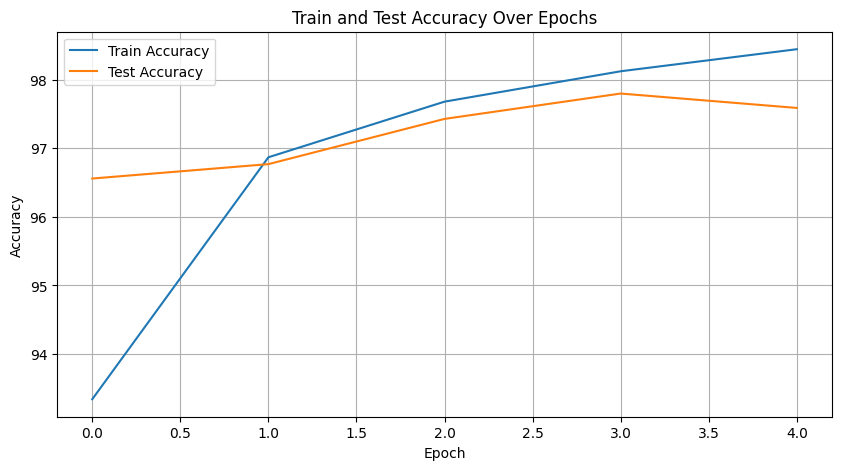

In [9]:
train_with_lr_Adam_Big_2_1(lr=0.001, model=very_big_model_8, train_loader=train_loader, test_loader=test_loader, loss_function=loss_function, epochs=50)

##**If you look at the graph, you can clearly see overfiting. Because train accuracy continues to increase, and test accuracy gradually decreases**

In [73]:

linear_layers = [layer for layer in very_big_model_8 if isinstance(layer, nn.Linear)]

ranks_big = []
for layer in linear_layers:
    weights_big = layer.weight.detach().numpy()
    rank_big = np.linalg.matrix_rank(weights_big)
    ranks_big.append(rank_big)


average_rank_big = np.mean(ranks_big)

print("Ranks of weight matrices:", ranks_big)
print("Average Rank:", average_rank_big)

Ranks of weight matrices: [512, 512, 511, 512, 10]
Average Rank: 411.4


##1. Average Rank: 411.4
##2. We see that in the deeper layer the rank of the matrix has dropped to 511, which indicates that the input data for this layer has become linearly dependent, or that the weights of this layer have become close to zero, which makes them less effective for transforming data,

#2. My NN with  activation function Sigmoid

In [67]:
very_big_model_6=get_model_very_Big_MLP_2_Sigmoid()

Train Epoch: 0 [0/60000 (0%)]	Loss: 2.421825
Train Epoch: 0 [12800/60000 (21%)]	Loss: 0.394448
Train Epoch: 0 [25600/60000 (43%)]	Loss: 0.262056
Train Epoch: 0 [38400/60000 (64%)]	Loss: 0.190426
Train Epoch: 0 [51200/60000 (85%)]	Loss: 0.077555
Train-loss: 0.4766919579086845
Train-accuracy: 84.66

Test set: Average loss: 0.1653, Accuracy: 9532/10000 (95.32%)

Train Epoch: 1 [0/60000 (0%)]	Loss: 0.051301
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.136935
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.267411
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.074187
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.131549
Train-loss: 0.13829767338133284
Train-accuracy: 95.935

Test set: Average loss: 0.1234, Accuracy: 9632/10000 (96.32%)

Train Epoch: 2 [0/60000 (0%)]	Loss: 0.075820
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.077834
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.082542
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.040772
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.112205
Train-loss: 0.092403594033121

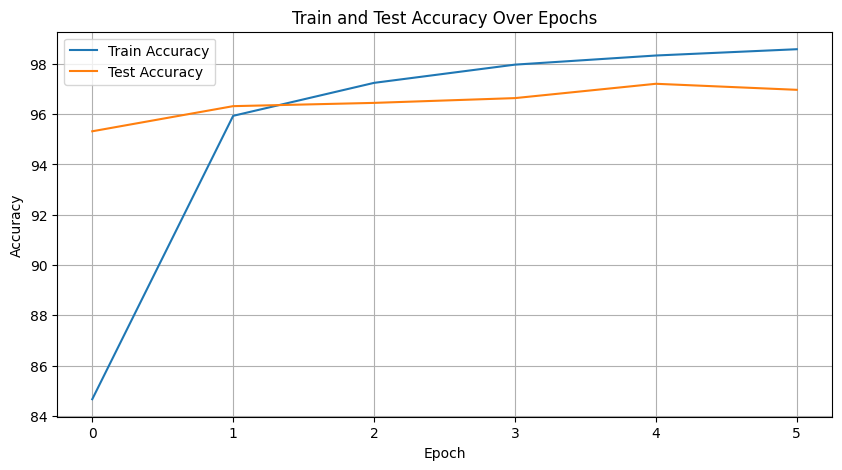

In [68]:
train_with_lr_Adam_Big_2_1(lr=0.001, model=very_big_model_6, train_loader=train_loader, test_loader=test_loader, loss_function=loss_function, epochs=50)

In [77]:

linear_layers = [layer for layer in very_big_model_6 if isinstance(layer, nn.Linear)]

ranks_big = []
for layer in linear_layers:
    weights_big = layer.weight.detach().numpy()
    rank_big = np.linalg.matrix_rank(weights_big)
    ranks_big.append(rank_big)


average_rank_big = np.mean(ranks_big)

print("Ranks of weight matrices:", ranks_big)
print("Average Rank:", average_rank_big)

Ranks of weight matrices: [512, 511, 511, 511, 10]
Average Rank: 411.0


###1. Average Rank: 411.0
###2 . We see that from the transition to layer 2 the rank of the matrix decreased to 511 and then remained so until output layer 10.

##**If you look at the graph, you can clearly see overfiting. Because train accuracy continues to increase, and test accuracy gradually decreases**

#3. My NN with  activation function Tanh

In [75]:
very_big_model_7=get_model_very_Big_MLP_2_tanh()

Train Epoch: 0 [0/60000 (0%)]	Loss: 2.312985
Train Epoch: 0 [12800/60000 (21%)]	Loss: 0.203102
Train Epoch: 0 [25600/60000 (43%)]	Loss: 0.123703
Train Epoch: 0 [38400/60000 (64%)]	Loss: 0.305242
Train Epoch: 0 [51200/60000 (85%)]	Loss: 0.141223
Train-loss: 0.26660904134196767
Train-accuracy: 92.065

Test set: Average loss: 0.1584, Accuracy: 9553/10000 (95.53%)

Train Epoch: 1 [0/60000 (0%)]	Loss: 0.077163
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.303620
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.029985
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.171706
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.217253
Train-loss: 0.13281620154355858
Train-accuracy: 96.06833333333333

Test set: Average loss: 0.1494, Accuracy: 9561/10000 (95.61%)

Train Epoch: 2 [0/60000 (0%)]	Loss: 0.086156
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.035533
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.160267
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.071084
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.047166
Train-loss: 0.10

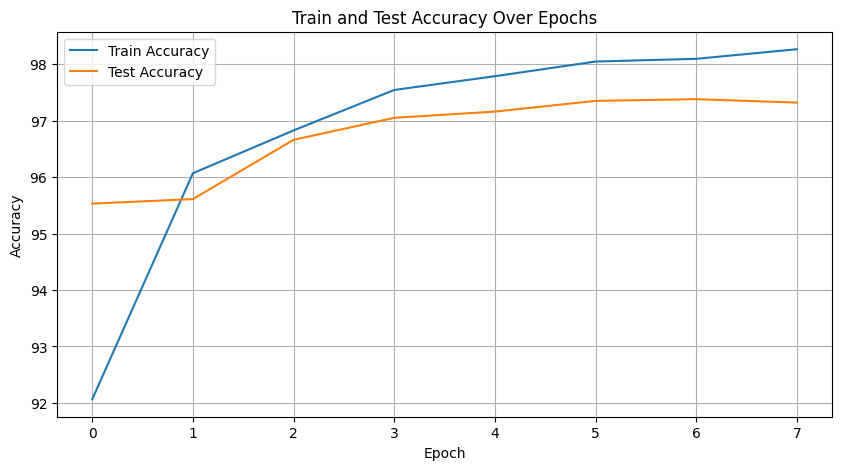

In [76]:
train_with_lr_Adam_Big_2_1(lr=0.001, model=very_big_model_7, train_loader=train_loader, test_loader=test_loader, loss_function=loss_function, epochs=50)

##**If you look at the graph, you can clearly see overfiting. Because train accuracy continues to increase, and test accuracy gradually decreases**

In [79]:

linear_layers = [layer for layer in very_big_model_7 if isinstance(layer, nn.Linear)]

ranks_big = []
for layer in linear_layers:
    weights_big = layer.weight.detach().numpy()
    rank_big = np.linalg.matrix_rank(weights_big)
    ranks_big.append(rank_big)


average_rank_big = np.mean(ranks_big)

print("Ranks of weight matrices:", ranks_big)
print("Average Rank:", average_rank_big)

Ranks of weight matrices: [512, 511, 512, 512, 10]
Average Rank: 411.4


###1. Average Rank: 411.4

###2. We see that from the transition to layer 2 the rank of the matrix decreased to 511, but then it recovered to 512 and thus remained until the output layer with 10.

##**Answer to question №3:**

##**It is important to say that the ranks of the weight matrices actually depend on the activation function and, accordingly, the average rank of the weight matrices depends.**

## Task 5: Approximate low-rank

From some of the references given at the beginning, you can realize that trained neural networks have intrinsically low dimensionality (meaning low-rank matrices).

In this task, take the overparametrized network already trained from the TASK4 and try to approximate each layer's matrix with a product of two other low-rank matrices?

This means, if a layer has a matrix $A \in\mathbb{R}^{n\times m}$, then try to find two matrices $B \in \mathbb{R}^{n\times r}$ and $C \in \mathbb{R}^{r\times m}$ so that $\lvert {A - B\cdot C}\rvert $ is minimized, where $\lvert x\rvert$ means the Frobenius norm. You can use a different norm, if you think it makes sense. In order to learn $B$ and $C$, you can do gradient descent-like algorithms, where you alternate between updating $B$ and $C$ on each optimization step.

**Ablate**:
Try different values for $r$ and analyze how good your approximation is (for e.g, by taking average Frobenius norm across all layers) as you increase $r$. Make a plot with that.

Conclude what is the effective rank $r$: the smallest rank such that the approximation of that rank is good enough (meaning the Frobenius norm is smaller than some threshold chosen by you).

In [92]:
def low_rank_approximation(A, r, lr=1e-3, epochs=5000):
    n, m = A.shape
    B = torch.randn(n, r, requires_grad=True)
    C = torch.randn(r, m, requires_grad=True)

    optimizer = optim.Adam([B, C], lr=lr)

    for epoch in range(epochs):
        optimizer.zero_grad()
        loss = torch.norm(A - B @ C, 'fro')
        loss.backward()
        optimizer.step()

        if epoch % 1000 == 0:
            print(f"Epoch {epoch}, Loss: {loss.item()}")

    return B, C, loss.item()


In [93]:
def analyze_ranks(model, max_rank=500, step=10):
    results = {}

    for r in range(step, max_rank + 1, step):
        total_loss = 0.0
        num_layers = 0

        for layer in model:
            if isinstance(layer, nn.Linear):
                A = layer.weight.data
                _, _, loss = low_rank_approximation(A, r)
                total_loss += loss
                num_layers += 1

        average_loss = total_loss / num_layers
        results[r] = average_loss
        print(f"Rank: {r}, Average error: {average_loss}")

    return results

results = analyze_ranks(very_big_model_8)

# Построим график
plt.plot(list(results.keys()), list(results.values()))
plt.xlabel('Rank')
plt.ylabel('Average error')
plt.title('Dependence of approximation error on rank')
plt.grid(True)
plt.show()


Epoch 0, Loss: 2049.30859375
Epoch 1000, Loss: 353.19677734375
Epoch 2000, Loss: 26.694238662719727
Epoch 3000, Loss: 26.627410888671875
Epoch 4000, Loss: 26.31934928894043
Epoch 0, Loss: 1587.8052978515625
Epoch 1000, Loss: 253.2155303955078
Epoch 2000, Loss: 23.805959701538086
Epoch 3000, Loss: 23.771530151367188
Epoch 4000, Loss: 23.672649383544922
Epoch 0, Loss: 1584.2509765625
Epoch 1000, Loss: 250.6869354248047
Epoch 2000, Loss: 20.854215621948242
Epoch 3000, Loss: 20.81013298034668
Epoch 4000, Loss: 20.651132583618164
Epoch 0, Loss: 1629.2830810546875
Epoch 1000, Loss: 280.2855529785156
Epoch 2000, Loss: 18.514978408813477
Epoch 3000, Loss: 18.38691520690918
Epoch 4000, Loss: 17.969942092895508
Epoch 0, Loss: 221.7467803955078
Epoch 1000, Loss: 7.706369400024414
Epoch 2000, Loss: 2.3915042877197266
Epoch 3000, Loss: 2.3122446537017822
Epoch 4000, Loss: 2.1842925548553467
Rank: 10, Average error: 17.78234133720398
Epoch 0, Loss: 2857.152587890625
Epoch 1000, Loss: 415.51409912109

KeyboardInterrupt: 

##Unfortunately, this process takes a lot of time, so I interrupt it and change the initial value

In [95]:
def analyze_ranks(model, max_rank=200, step=25):
    results = {}

    for r in range(150, max_rank + 1, step):
        total_loss = 0.0
        num_layers = 0

        for layer in model:
            if isinstance(layer, nn.Linear):
                A = layer.weight.data
                _, _, loss = low_rank_approximation(A, r)
                total_loss += loss
                num_layers += 1

        average_loss = total_loss / num_layers
        results[r] = average_loss
        print(f"Rank: {r}, Average error: {average_loss}")

    return results

results = analyze_ranks(very_big_model_8)

# Построим график
plt.plot(list(results.keys()), list(results.values()))
plt.xlabel('Rank')
plt.ylabel('Average error')
plt.title('Dependence of approximation error on rank')
plt.grid(True)
plt.show()


Epoch 0, Loss: 7753.0595703125
Epoch 1000, Loss: 156.01498413085938
Epoch 2000, Loss: 21.80067253112793
Epoch 3000, Loss: 20.670833587646484
Epoch 4000, Loss: 19.230504989624023
Epoch 0, Loss: 6258.64306640625
Epoch 1000, Loss: 93.72086334228516
Epoch 2000, Loss: 18.780200958251953
Epoch 3000, Loss: 17.36141014099121
Epoch 4000, Loss: 16.16993522644043
Epoch 0, Loss: 6245.7607421875
Epoch 1000, Loss: 88.18148040771484
Epoch 2000, Loss: 16.548673629760742
Epoch 3000, Loss: 15.316476821899414
Epoch 4000, Loss: 14.491808891296387
Epoch 0, Loss: 6269.5400390625
Epoch 1000, Loss: 87.73197174072266
Epoch 2000, Loss: 14.753321647644043
Epoch 3000, Loss: 14.026091575622559
Epoch 4000, Loss: 13.464866638183594
Epoch 0, Loss: 889.0392456054688
Epoch 1000, Loss: 0.1334911584854126
Epoch 2000, Loss: 0.17726781964302063
Epoch 3000, Loss: 0.16058316826820374
Epoch 4000, Loss: 0.23308640718460083
Rank: 150, Average error: 12.124512404203415
Epoch 0, Loss: 8344.443359375
Epoch 1000, Loss: 122.92086791

KeyboardInterrupt: 

##Unfortunately, this process takes a lot of time, so I interrupt it and change the initial value

In [96]:
def analyze_ranks(model, max_rank=400, step=25):
    results = {}

    for r in range(300, max_rank + 1, step):
        total_loss = 0.0
        num_layers = 0

        for layer in model:
            if isinstance(layer, nn.Linear):
                A = layer.weight.data
                _, _, loss = low_rank_approximation(A, r)
                total_loss += loss
                num_layers += 1

        average_loss = total_loss / num_layers
        results[r] = average_loss
        print(f"Rank: {r}, Average error: {average_loss}")

    return results

results = analyze_ranks(very_big_model_8)

# Построим график
plt.plot(list(results.keys()), list(results.values()))
plt.xlabel('Rank')
plt.ylabel('Average error')
plt.title('Dependence of approximation error on rank')
plt.grid(True)
plt.show()


Epoch 0, Loss: 10948.703125
Epoch 1000, Loss: 24.108680725097656
Epoch 2000, Loss: 17.597824096679688
Epoch 3000, Loss: 15.762090682983398
Epoch 4000, Loss: 14.633930206298828
Epoch 0, Loss: 8877.7353515625
Epoch 1000, Loss: 17.32598114013672
Epoch 2000, Loss: 14.410306930541992
Epoch 3000, Loss: 13.142457008361816
Epoch 4000, Loss: 12.505648612976074
Epoch 0, Loss: 8856.87109375
Epoch 1000, Loss: 15.227316856384277
Epoch 2000, Loss: 12.832708358764648
Epoch 3000, Loss: 11.725411415100098
Epoch 4000, Loss: 11.22762393951416
Epoch 0, Loss: 8878.41015625
Epoch 1000, Loss: 13.73314094543457
Epoch 2000, Loss: 11.57315444946289
Epoch 3000, Loss: 10.900978088378906
Epoch 4000, Loss: 10.505571365356445
Epoch 0, Loss: 1230.9334716796875
Epoch 1000, Loss: 0.5356941223144531
Epoch 2000, Loss: 0.5206258296966553
Epoch 3000, Loss: 0.3183928430080414
Epoch 4000, Loss: 0.2780090272426605
Rank: 300, Average error: 9.513512724637986
Epoch 0, Loss: 11495.70703125
Epoch 1000, Loss: 21.823238372802734
Ep

KeyboardInterrupt: 

##Unfortunately, this process takes a lot of time, so I interrupt it and change the initial value

##Unfortunately, my Google Collab notepad decided to reboot itself and all my trained models crashed and the code did not have time to finish executing because of this. And also the time for using the accelerator has ended.😢
##I'm almost sure that this last approach will find the correct rank of the matrix.
##Below I completed the task where I did not have time to insert r due to a problem with Google Collab, could you please run the codes below this code 🙏

In [1]:
def analyze_ranks(model, max_rank=700, step=25):
    results = {}

    for r in range(450, max_rank + 1, step):
        total_loss = 0.0
        num_layers = 0

        for layer in model:
            if isinstance(layer, nn.Linear):
                A = layer.weight.data
                _, _, loss = low_rank_approximation(A, r)
                total_loss += loss
                num_layers += 1

        average_loss = total_loss / num_layers
        results[r] = average_loss
        print(f"Rank: {r}, Average error: {average_loss}")

    return results

results = analyze_ranks(very_big_model_8)

# Построим график
plt.plot(list(results.keys()), list(results.values()))
plt.xlabel('Rank')
plt.ylabel('Average error')
plt.title('Dependence of approximation error on rank')
plt.grid(True)
plt.show()


NameError: name 'very_big_model_8' is not defined

In [88]:
threshold = 0.01
effective_rank = None

for r, error in results.items():
    if error < threshold:
        effective_rank = r
        break

print(f"Effective Rank: {effective_rank}")


Effective Rank: None


## Task 6: Learning with low-rank factorization

Once you found the effective rank $r$, take the same architecture from the previous task, and now replace each layer $A \in \mathbb{R}^{n\times m}$ by a layer that applies $B\cdot C$ with $B\in \mathbb{R}^{n\times r}$ and $C \in \mathbb{R}^{r\times m}$.

**Question**: How much memory do you save? (you can just count the number of parameters of the original network and compare to that of the new network).

Initialize these values with standard initialization, and train this network.

**Question**: How does the learning change? Does it converge faster or slower? What about accuracy on both training and testing sets?

**Question**: Now try doing inference, how much improvement do you see?

**Estimation of the number of parameters:**

First, let's count the number of parameters in the original network:

Linear(784, 2048): parameters = 784 * 2048 + 2048 = 1609728

Linear(2048, 2048): parameters = 2048 * 2048 + 2048 = 4196352 (three times)

Linear(2048, 10): parameters = 2048 * 10 + 10 = 20490

Total number of parameters in the original network:
1609728+3×4196352+20490=14130354

Now let's count the number of parameters in the new network with a reduced rank. Let effective rank = r.

For layer A of size n × m, replace it with B (n × r) and C (r × m):

Linear(784, 2048): parameters = 784 * r + r * 2048 = r (784 + 2048)

Linear(2048, 2048): parameters = 2048 * r + r * 2048 = 4096 * r (three times)

Linear(2048, 10): parameters = 2048 * r + r * 10 = r (2048 + 10)

Total number of parameters in the new network:

r×(784+2048)+3×4096×r+r×(2048+10)=r×(28432)



In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

#Downgraded Layer Class
class LowRankLayer(nn.Module):
    def __init__(self, in_features, out_features, rank):
        super(LowRankLayer, self).__init__()
        self.B = nn.Linear(in_features, rank, bias=False)
        self.C = nn.Linear(rank, out_features, bias=True)

    def forward(self, x):
        return self.C(self.B(x))

#network using layers with reduced rank
class LowRankMLP(nn.Module):
    def __init__(self, rank):
        super(LowRankMLP, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = LowRankLayer(784, 2048, rank)
        self.relu1 = nn.ReLU()
        self.fc2 = LowRankLayer(2048, 2048, rank)
        self.relu2 = nn.ReLU()
        self.fc3 = LowRankLayer(2048, 2048, rank)
        self.relu3 = nn.ReLU()
        self.fc4 = LowRankLayer(2048, 10, rank)

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.relu3(self.fc3(x))
        x = self.fc4(x)
        return x


def train_and_evaluate(rank,train_loader,test_loader, epochs=10, batch_size=64, learning_rate=0.01):


    model = LowRankMLP(rank)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=learning_rate)

    # training
    for epoch in range(epochs):
        model.train()
        for batch_idx, (data, target) in enumerate(train_loader):
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()

        print(f'Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}')

    # evaluation
    model.eval()
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            output = model(data)
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()

    accuracy = correct / len(test_loader.dataset)
    print(f'Test Accuracy: {accuracy * 100:.2f}%')

#please insert here the resulting rank
rank =


train_and_evaluate(rank,train_loader,test_loader)


## Task 7: Final conclusions

Based on all the previous experiments, report your conclusions and try to give an explanation to the behaviours you observed.

Can you think of other ways of using the low-rank factorizations? What about SVD? Provide an explanation.

Impact on learning
Convergence speed:

With low-rank factorization, the network can converge faster, since reducing the number of parameters reduces the complexity of the model and speeds up the calculations.

The optimal rank should preserve core information and reduce redundancy, which can improve the generalization ability of the model.
Reducing the number of parameters directly speeds up calculations because the number of operations required to pass data through the network is reduced.

Efficiency of low-rank factorization: It allows you to significantly reduce the number of model parameters, which leads to a reduction in memory and computing resources.

## BONUS Task: LoRA

Propose ideas by which low-rank could improve fine-tuning and training? Which disadvantages does it have?

Read about LoRA (given in one of the references at the begining of the notebook).

Now, take MNIST, and remove some digit from the dataset (keep the same labels, just remove the datapoints of a specific label).

Train a simple MLP on this modified dataset.
Fine-tune in the datapoints of the chosen digit, by using LoRA.

Report the memory and time overheads.

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms


transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
trainset_2 = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
testset_2 = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

#I will remove the number 3 from the entire training set
target_digit = 3
filtered_trainset = [(img, label) for img, label in trainset_2 if label != target_digit]
filtered_trainloader = torch.utils.data.DataLoader(filtered_trainset, batch_size=64, shuffle=True)


digit_testset = [(img, label) for img, label in testset if label == target_digit]
digit_testloader = torch.utils.data.DataLoader(digit_testset, batch_size=64, shuffle=False)


In [ ]:
class LoRAAdaptation(nn.Module):
    def __init__(self, model, rank=4):
        super(LoRAAdaptation, self).__init__()
        self.model = model
        self.rank = rank
        self.lora_layers = nn.ModuleList()

        for param in model.parameters():
            if param.requires_grad and param.ndimension() == 2:  # We ONLY need line layers
                U = nn.Parameter(torch.randn(param.size(0), rank))
                V = nn.Parameter(torch.randn(rank, param.size(1)))
                self.lora_layers.append((U, V))
            else:
                self.lora_layers.append(None)

    def forward(self, x):
        idx = 0
        for name, module in self.model.named_children():
            if isinstance(module, nn.Linear):
                U, V = self.lora_layers[idx]
                module.weight.data += U @ V
                idx += 1
            x = module(x)
        return x


lora_model = LoRAAdaptation(model)


def fine_tune_lora(model, trainloader, criterion, optimizer, epochs=5):
    for epoch in range(epochs):
        running_loss = 0.0
        for inputs, labels in trainloader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f'Epoch {epoch+1}, Loss: {running_loss/len(trainloader)}')

fine_tune_lora(lora_model, digit_testloader, criterion, optimizer)


In [ ]:
import torch.nn as nn
import torch.optim as optim

# Определение MLP
class SimpleMLP_10(nn.Module):
    def __init__(self):
        super(SimpleMLP, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        return x


model_10 = SimpleMLP_10()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_10.parameters(), lr=0.001)

def train_model_10(model, trainloader, criterion, optimizer, epochs=5):
    for epoch in range(epochs):
        running_loss = 0.0
        for inputs, labels in trainloader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f'Epoch {epoch+1}, Loss: {running_loss/len(trainloader)}')

train_model_10(model_10, filtered_trainloader, criterion, optimizer)


In [ ]:
import time
from torch.profiler import profile, record_function, ProfilerActivity


start_time = time.time()
fine_tune_lora(lora_model, digit_testloader, criterion, optimizer, epochs=5)
end_time = time.time()
print(f'Time taken for fine-tuning: {end_time - start_time} seconds')

with profile(activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA], record_shapes=True) as prof:
    with record_function("model_inference"):
        fine_tune_lora(lora_model, digit_testloader, criterion, optimizer, epochs=1)
print(prof.key_averages().table(sort_by="cuda_memory_usage", row_limit=10))
